<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkST0151ENSkillsNetwork20531532-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>



#### Import the required libraries we need for the lab.


In [2]:
import piplite
await piplite.install(['numpy'],['pandas'])
await piplite.install(['seaborn'])

In [3]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

<ipython-input-3-975bf9c6861f>:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


#### Read the dataset in the csv file from the URL


In [4]:
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = await fetch(URL)
boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())

In [5]:
b_df=pd.read_csv(boston_url)

#### Add your code below following the instructions given in the course to complete the peer graded assignment


In [6]:
b_df.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


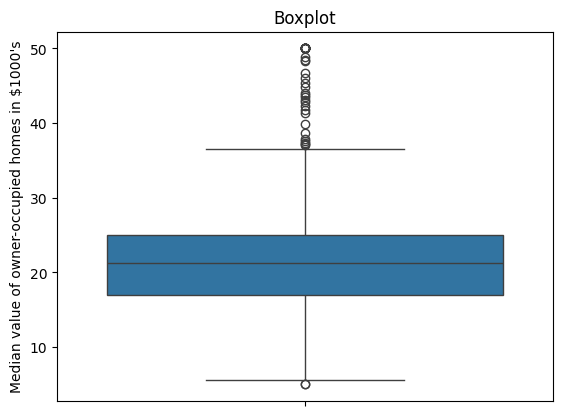

In [12]:
ax = sns.boxplot(y='MEDV', data=b_df)
ax.set_title('Boxplot')
ax.set_ylabel("""Median value of owner-occupied homes in $1000's""")
plt.show()

In [16]:
print(f" mean value {b_df['MEDV'].mean():.2f} and median {b_df['MEDV'].median()}, min {b_df['MEDV'].min()} - max {b_df['MEDV'].max()}")

 mean value 22.53 and median 21.2, min 5.0 - max 50.0


#### 1. Is there a significant difference in the median value of houses bounded by the Charles river or not?

In [17]:
medv_chas = b_df.groupby('CHAS')[['MEDV']].mean().reset_index()
print("""mean values of Median value of owner-occupied homes in $1000's bounded by the Charles river or not""")
medv_chas

mean values of Median value of owner-occupied homes in $1000's bounded by the Charles river or not


,CHAS,MEDV
0,0.0,22.093843
1,1.0,28.440000


In [23]:
print(f" mean value of houses bounded by the river {medv_chas.loc[1,'MEDV']:.2f} is higher then not {medv_chas.loc[0,'MEDV']:.2f}")

 mean value of houses bounded by the river 28.44 is higher then not 22.09


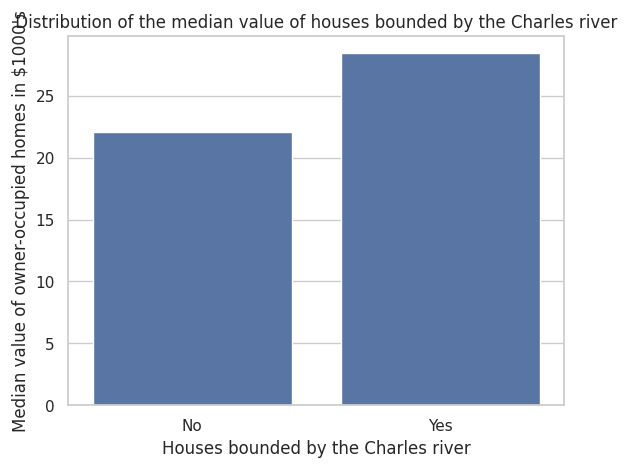

In [19]:
sns.set(style="whitegrid")
ax = sns.barplot(x="CHAS", y="MEDV", data=medv_chas)
ax.set_title(' Distribution of the median value of houses bounded by the Charles river ')
ax.set_ylabel("""Median value of owner-occupied homes in $1000's""")
ax.set_xlabel('Houses bounded by the Charles river')
ax.set_xticks([0,1])
ax.set_xticklabels(['No','Yes'])
plt.show()

In [20]:
print('State the hypothesis:')
print('H0: there is no difference in the median value of houses bounded by the Charles river or not')
print('H1: there is a difference in the median value of houses bounded by the Charles river or not')
print('')
ss1 = scipy.stats.ttest_ind(b_df[b_df['CHAS'] == 0]['MEDV'],
                   b_df[b_df['CHAS'] == 1]['MEDV'], equal_var = True)
print(f"statystic t-stat {ss1[0]}, p-value {ss1[1]}")
print('')
if ss1[1] <0.05:
    print("""Conclusion: Since the p-value is less than alpha value 0.05, we reject the null hypothesis as there is enough proof that 
there is a difference in the median value of houses bounded by the Charles river or not""")
else:
    print('Conclusion: Since the p-value is not less than alpha value 0.05, we do not have enought proof to reject null hypothesis')

State the hypothesis:
H0: there is no difference in the median value of houses bounded by the Charles river or not
H1: there is a difference in the median value of houses bounded by the Charles river or not

statystic t-stat -3.996437466090509, p-value 7.390623170519905e-05

Conclusion: Since the p-value is less than alpha value 0.05, we reject the null hypothesis as there is enough proof that 
there is a difference in the median value of houses bounded by the Charles river or not


#### 2. Is there a difference in median values of houses of each proportion of owner-occupied units built before 1940?

In [25]:
import numpy as np
b_df['age group'] = np.where(b_df['AGE']<=35,1,2)
b_df['age group'] = np.where(b_df['AGE']>=70,3,b_df['age group'])
b_df.groupby('age group')[['MEDV']].mean().reset_index()


,age group,MEDV
0,1,27.775824
1,2,24.947656
2,3,19.793380


In [30]:
print(f" mean value of houses is the higest for group age 35y and younger {b_df.groupby('age group')[['MEDV']].mean().reset_index().loc[0,'MEDV']:.2f} and the lowest for group age 70Y or older {b_df.groupby('age group')[['MEDV']].mean().reset_index().loc[2,'MEDV']:.2f}")

 mean value of houses is the higest for group age 35y and younger 27.78 and the lowest for group age 70Y or older 19.79


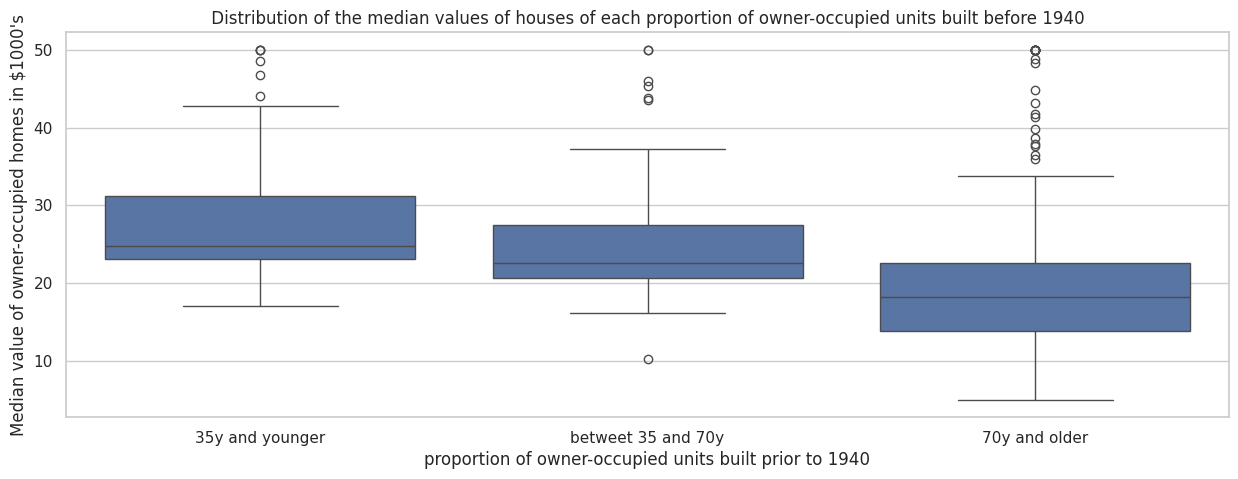

In [28]:
fig, (ax) = plt.subplots(1,1,figsize=(15,5))
ax = sns.boxplot(x='age group', y='MEDV', data=b_df)
ax.set_title(' Distribution of the median values of houses of each proportion of owner-occupied units built before 1940 ')
ax.set_ylabel("""Median value of owner-occupied homes in $1000's""")
ax.set_xticks([0,1,2])
ax.set_xticklabels(['35y and younger','betweet 35 and 70y','70y and older'])
ax.set_xlabel('proportion of owner-occupied units built prior to 1940')
plt.show()

In [31]:
age_group1 = b_df[b_df['age group'] == 1]['MEDV']
age_group2 = b_df[b_df['age group'] == 2]['MEDV']
age_group3 = b_df[b_df['age group'] == 3]['MEDV']
f_statistic, p_value = scipy.stats.f_oneway(age_group1 , age_group2 , age_group3 )


In [32]:
print('State the hypothesis:')
print('H0: the three population means are equal')
print('H1: At least one of the means differ')
print('')
print("F_Statistic: {0}, P-Value: {1}".format(f_statistic,p_value))
print('')
if p_value <0.05:
    print("""Conclusion: Since the p-value is less than alpha value 0.05, we reject the null hypothesis as there is enough proof that 
there a difference in median values of houses of each proportion of owner-occupied units built before 1940""")
else:
    print('Conclusion: Since the p-value is not less than alpha value 0.05, we do not have enought proof to reject null hypothesis')

State the hypothesis:
H0: the three population means are equal
H1: At least one of the means differ

F_Statistic: 36.40764999196599, P-Value: 1.7105011022702984e-15

Conclusion: Since the p-value is less than alpha value 0.05, we reject the null hypothesis as there is enough proof that 
there a difference in median values of houses of each proportion of owner-occupied units built before 1940


#### 3. Can we conclude that there is no relationship between Nitric oxide concentrations and the proportion of non-retail business acres per town?

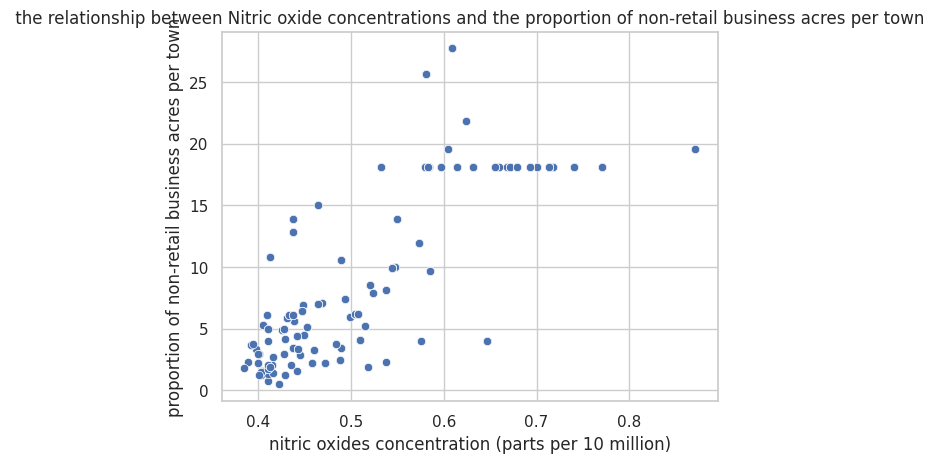

In [33]:
ax= sns.scatterplot(x='NOX', y='INDUS', data=b_df)
ax.set_title(' the relationship between Nitric oxide concentrations and the proportion of non-retail business acres per town ')
ax.set_ylabel("""proportion of non-retail business acres per town""")
ax.set_xlabel('nitric oxides concentration (parts per 10 million)')
plt.show()

In [34]:
print('State the hypothesis:')
print('H0: Nitric oxide concentrations is not corelated with the proportion of non-retail business acres per town')
print('H1: Nitric oxide concentrations is corelated with the proportion of non-retail business acres per town')
print('')
ss3 = scipy.stats.pearsonr(b_df['NOX'], b_df['INDUS'])
print(f"t-stat {ss3[0]}, p-value {ss3[1]}")
print('')
if ss3[1] <0.05:
    print("""Conclusion: Since the p-value is less than alpha value 0.05, we reject the null hypothesis as there is enough proof that 
there is relationship between Nitric oxide concentrations and the proportion of non-retail business acres per town""")
else:
    print('Conclusion: Since the p-value is not less than alpha value 0.05, we do not have enought proof to reject null hypothesis')

State the hypothesis:
H0: Nitric oxide concentrations is not corelated with the proportion of non-retail business acres per town
H1: Nitric oxide concentrations is corelated with the proportion of non-retail business acres per town

t-stat 0.7636514469209192, p-value 7.913361061210442e-98

Conclusion: Since the p-value is less than alpha value 0.05, we reject the null hypothesis as there is enough proof that 
there is relationship between Nitric oxide concentrations and the proportion of non-retail business acres per town


#### 4. What is the impact of an additional weighted distance to the five Boston employment centres on the median value of owner-occupied homes?

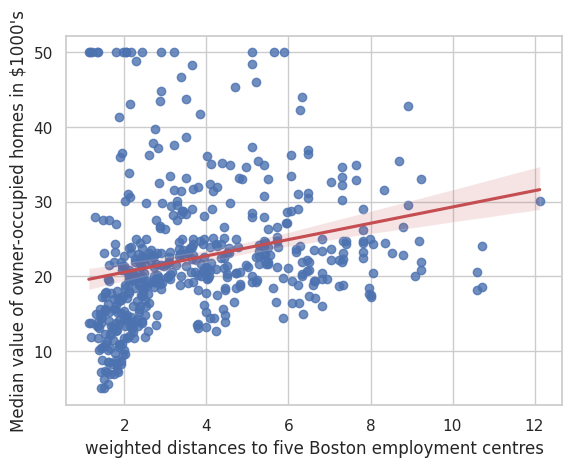

In [37]:
ax=sns.regplot(x='DIS', y='MEDV', line_kws={"color":'r'},data=b_df, scatter=True)
ax.set_ylabel("""Median value of owner-occupied homes in $1000's""")
ax.set_xlabel('weighted distances to five Boston employment centres')
plt.show()

In [37]:
X=b_df['DIS']
y= b_df['MEDV']
X=sm.add_constant(X)

model = sm.OLS(y, X).fit()
predictions = model.predict(X)

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Wed, 08 Jan 2025   Prob (F-statistic):           1.21e-08
Time:                        13:33:27   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.000      16.784      19.996
DIS            1.0916      0.188      5.795      0.000       0.722       1.462
==============================================================================
Omnibus:                      139.779   Durbin-Watson:                   0.570
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              305.104
Skew:                           1.466   Prob(JB):                     5.59e-67
Kurtosis:                       5.424   Cond. No.                         9.32
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [38]:
print('H0: coef = 0 (distance to the five Boston employment centres has no effect on the median value of owner-occupied homes)')
print('H1: coef differ then 0 (distance to the five Boston employment centres has effect on the median value of owner-occupied homes)')
print('')
print('')
print("""Since the p-value of model and coef DIS  are less than alpha value 0.05, we reject the null hypothesis as there is enough proof that 
so distance to the five Boston employment centres has effect on the median value of owner-occupied homes""")


H0: coef = 0 (distance to the five Boston employment centres has no effect on the median value of owner-occupied homes)
H1: coef differ then 0 (distance to the five Boston employment centres has effect on the median value of owner-occupied homes)


Since the p-value of model and coef DIS  are less than alpha value 0.05, we reject the null hypothesis as there is enough proof that 
so distance to the five Boston employment centres has effect on the median value of owner-occupied homes


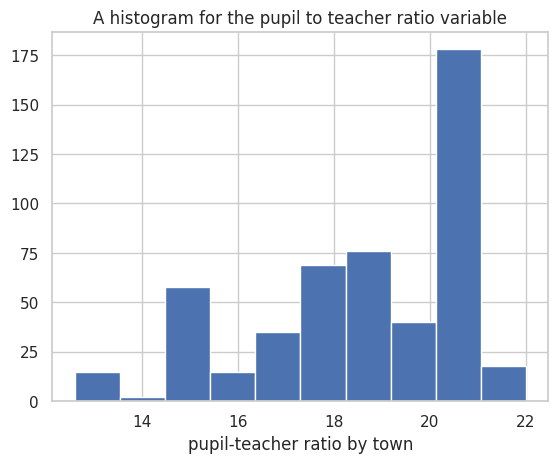

In [41]:
ax = b_df['PTRATIO'].hist()
ax.set_title('A histogram for the pupil to teacher ratio variable')
ax.set_xlabel('pupil-teacher ratio by town')
plt.show()